<a href="https://colab.research.google.com/github/varunkamuni1609/fraud-detection-analysis/blob/main/FRAUD_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# EXPLORATORY DATA ANALYSIS (EDA) - DATA PREPROCESSING
# Descriptive analysis
# Import pandas for data handling
import pandas as pd
# Import numpy for numerical operations
import numpy as np

# Load the dataset
url = r"C:\Users\mythr\Downloads\Fraud Detection.csv"
#Read the dataset using pandas
df = pd.read_csv(url)

In [ ]:
# Convert Time column from seconds to hours
df['Time_hours'] = df['Time'] / 3600

# Create sine and cosine transformation for cyclical time
df['Time_sin'] = np.sin(2 * np.pi * df['Time_hours'] / 24)
df['Time_cos'] = np.cos(2 * np.pi * df['Time_hours'] / 24)

# Drop original Time column
df.drop(columns=['Time'], inplace=True)

# Interpretation:
# Time is converted into cyclical features to capture fraud patterns at different times of day

In [ ]:
# Normalize the Amount column
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Apply normalization on Amount column
df['Amount'] = scaler.fit_transform(df[['Amount']])

# Interpretation: Amount is now on the same scale as other features

In [ ]:
# Display first 5 rows to confirm data is loaded correctly
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Amount,Class,Time_hours,Time_sin,Time_cos
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0,0.000000,0.000000,1.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0,0.000000,0.000000,1.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0,0.000278,0.000073,1.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0,0.000278,0.000073,1.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0,0.000556,0.000145,1.0


In [ ]:
# Check number of rows and columns
df.shape

(284807, 33)

In [ ]:
# Display all column names
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class',
       'Time_hours', 'Time_sin', 'Time_cos'],
      dtype='object')

In [ ]:
# Get dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 33 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   V1          284807 non-null  float64
 1   V2          284807 non-null  float64
 2   V3          284807 non-null  float64
 3   V4          284807 non-null  float64
 4   V5          284807 non-null  float64
 5   V6          284807 non-null  float64
 6   V7          284807 non-null  float64
 7   V8          284807 non-null  float64
 8   V9          284807 non-null  float64
 9   V10         284807 non-null  float64
 10  V11         284807 non-null  float64
 11  V12         284807 non-null  float64
 12  V13         284807 non-null  float64
 13  V14         284807 non-null  float64
 14  V15         284807 non-null  float64
 15  V16         284807 non-null  float64
 16  V17         284807 non-null  float64
 17  V18         284807 non-null  float64
 18  V19         284807 non-null  float64
 19  V2

In [ ]:
# Null value check
df.isnull().sum()

V1            0
V2            0
V3            0
V4            0
V5            0
V6            0
V7            0
V8            0
V9            0
V10           0
V11           0
V12           0
V13           0
V14           0
V15           0
V16           0
V17           0
V18           0
V19           0
V20           0
V21           0
V22           0
V23           0
V24           0
V25           0
V26           0
V27           0
V28           0
Amount        0
Class         0
Time_hours    0
Time_sin      0
Time_cos      0
dtype: int64

In [ ]:
# Generate descriptive statistics
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Amount,Class,Time_hours,Time_sin,Time_cos
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000,284807.000000,284807.000000
mean,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,...,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,2.913952e-17,0.001727,26.337183,-0.266787,-0.140733
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,...,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,1.000002e+00,0.041527,13.191152,0.628132,0.717268
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,...,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,-3.532294e-01,0.000000,0.000000,-1.000000,-1.000000
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,...,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,-3.308401e-01,0.000000,15.055972,-0.841236,-0.837083
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,...,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,-2.652715e-01,0.000000,23.525556,-0.435624,-0.311920
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,...,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,-4.471707e-02,0.000000,38.700139,0.247422,0.597800
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,...,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,1.023622e+02,1.000000,47.997778,1.000000,1.000000


In [ ]:
# Create a descriptive summary table (rounded to 2 decimals)
descriptive_summary = pd.DataFrame({
    "Mean": df.mean().round(2),      # Average value of each column
    "Median": df.median().round(2),  # Middle value of each column
    "Mode": df.mode().iloc[0].round(2),  # Most frequent value
    "Min": df.min().round(2),        # Minimum value
    "Max": df.max().round(2),        # Maximum value
    "Null_Count": df.isnull().sum()  # Missing values count
})

# Display the summary table
descriptive_summary

,Mean,Median,Mode,Min,Max,Null_Count
V1,0.00,0.02,1.25,-56.41,2.45,0
V2,0.00,0.07,-0.33,-72.72,22.06,0
V3,-0.00,0.18,-2.75,-48.33,9.38,0
V4,0.00,-0.02,-0.84,-5.68,16.88,0
V5,0.00,-0.05,-0.56,-113.74,34.80,0
V6,0.00,-0.27,-1.01,-26.16,73.30,0
V7,-0.00,0.04,-0.43,-43.56,120.59,0
V8,0.00,0.02,-0.16,-73.22,20.01,0
V9,-0.00,-0.05,0.17,-13.43,15.59,0
V10,0.00,-0.09,-0.08,-24.59,23.75,0


In [ ]:
# Distribution analysis
# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations
import seaborn as sns

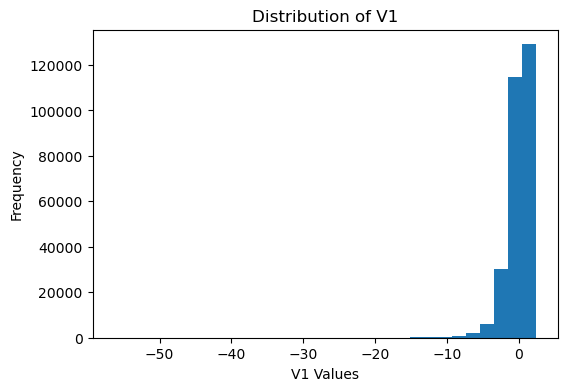

In [ ]:
# Plot histogram for V1 to understand its distribution
plt.figure(figsize=(6,4))
plt.hist(df['V1'], bins=30)
plt.xlabel('V1 Values')
plt.ylabel('Frequency')
plt.title('Distribution of V1')
plt.show()

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


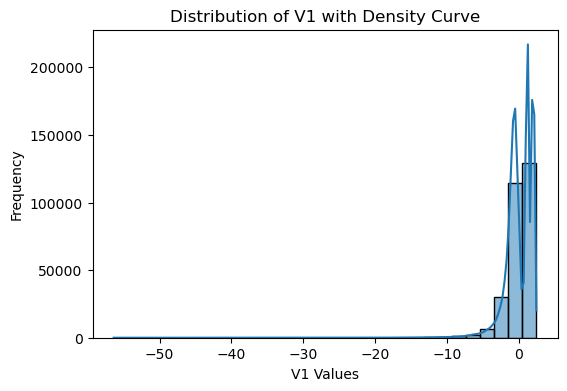

In [ ]:
# Plot histogram with KDE (density curve) for V1
plt.figure(figsize=(6,4))
sns.histplot(df['V1'], bins=30, kde=True)
plt.xlabel('V1 Values')
plt.ylabel('Frequency')
plt.title('Distribution of V1 with Density Curve')
plt.show()

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


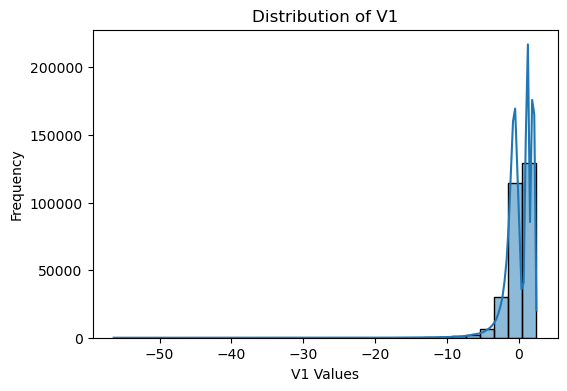

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


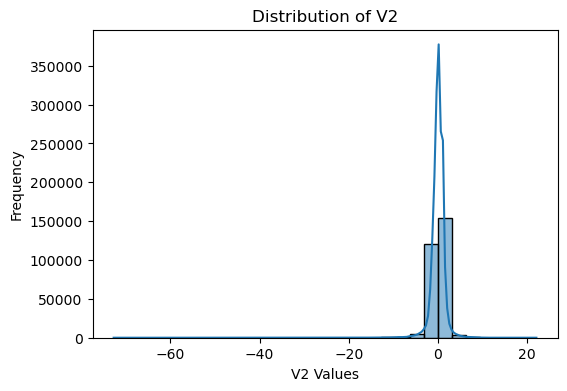

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


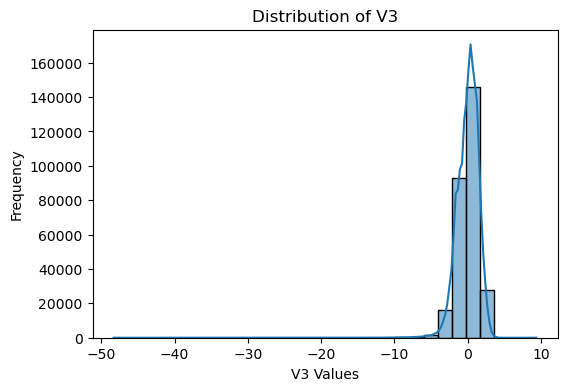

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


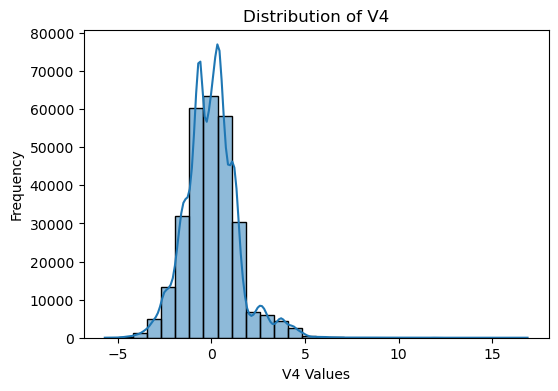

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


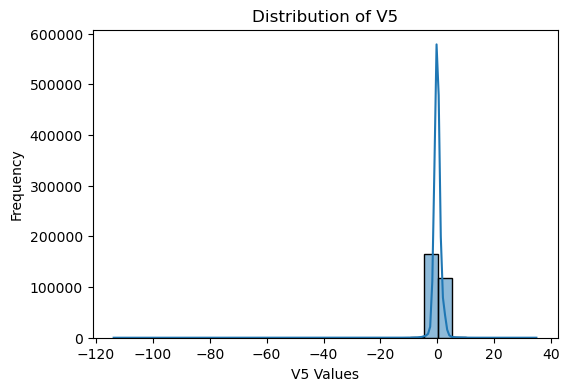

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


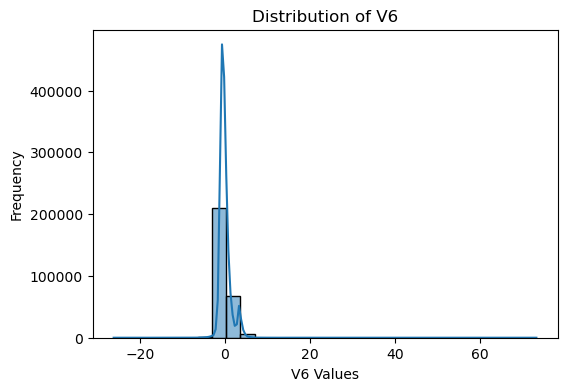

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


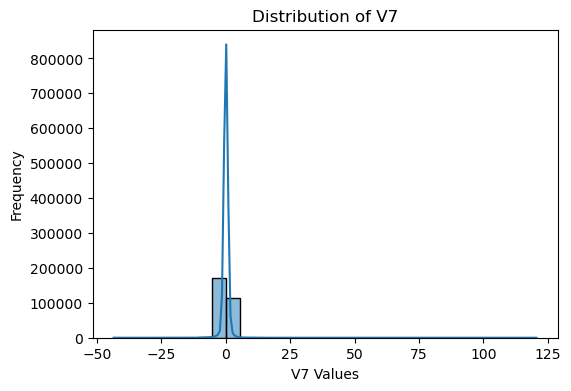

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


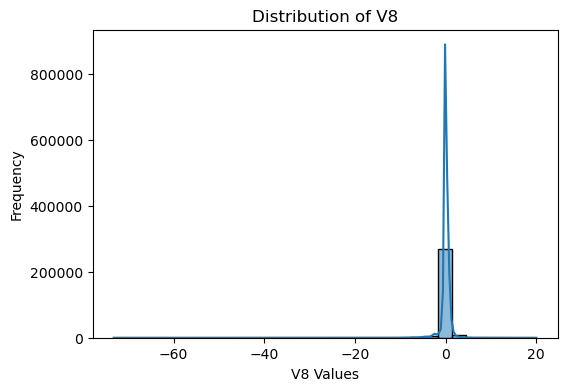

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


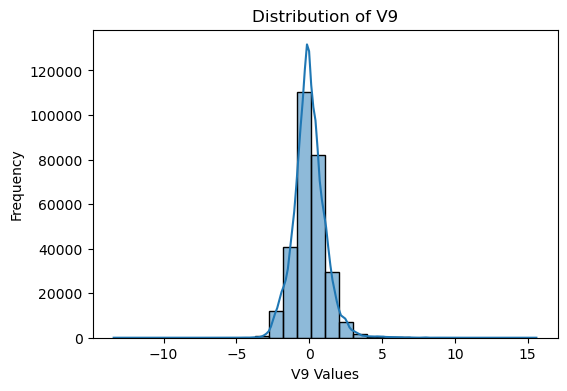

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


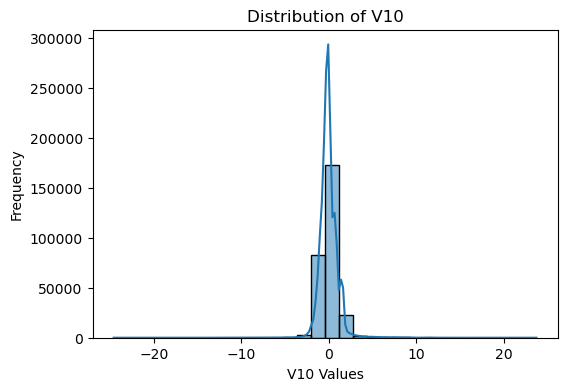

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


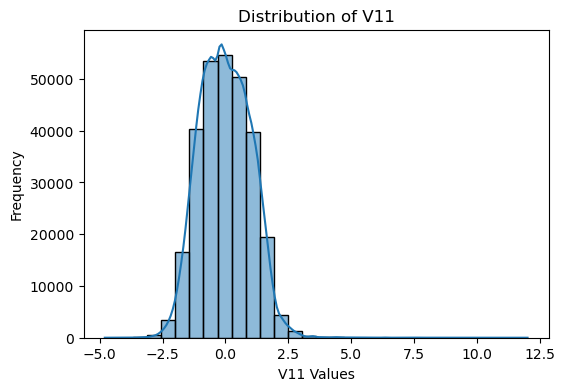

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


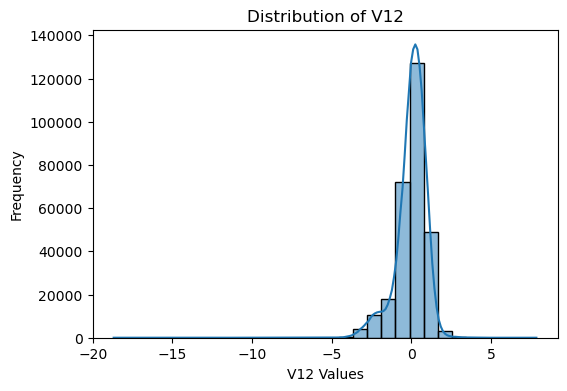

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


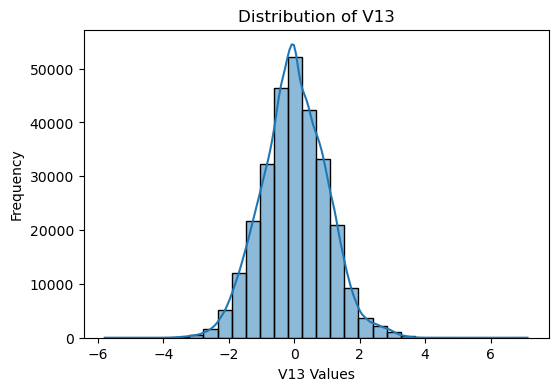

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


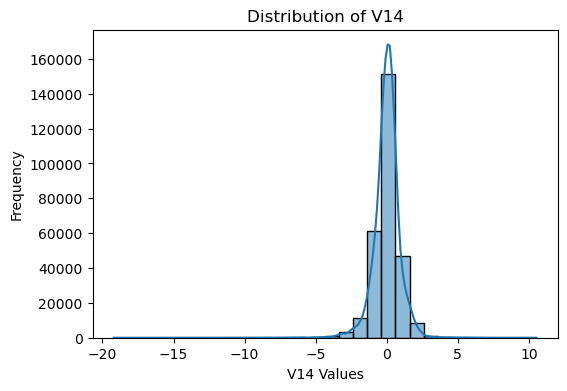

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


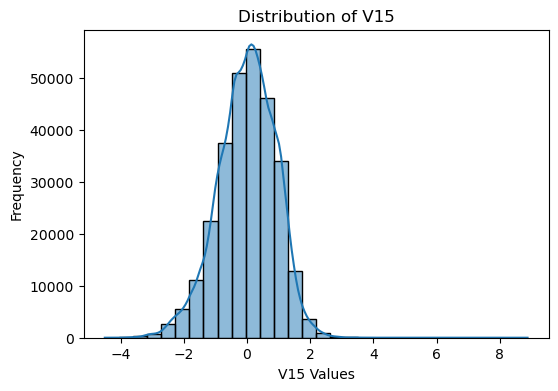

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


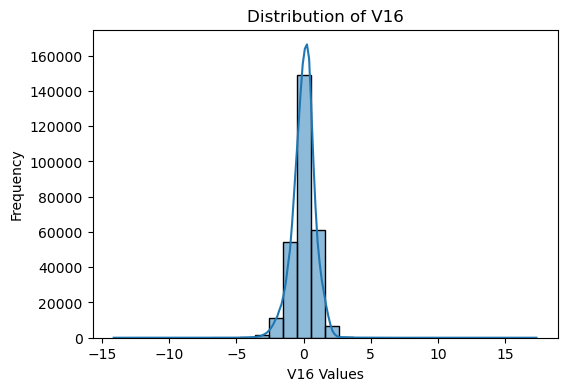

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


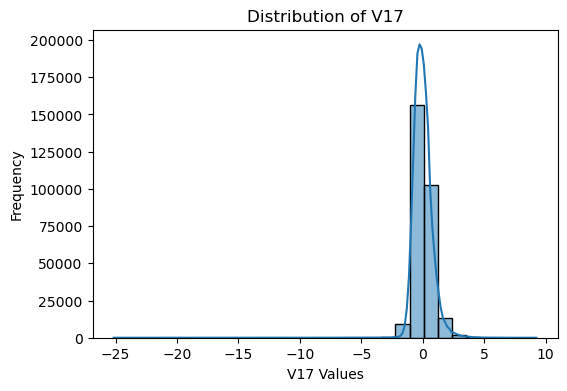

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


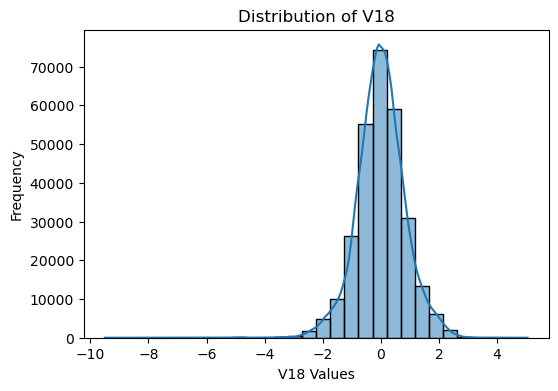

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


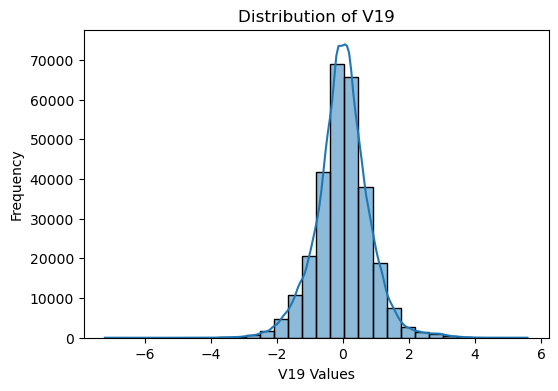

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


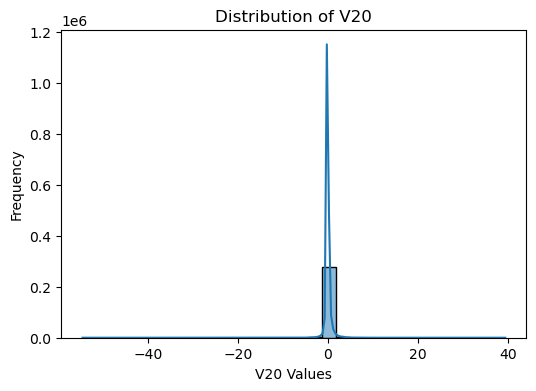

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


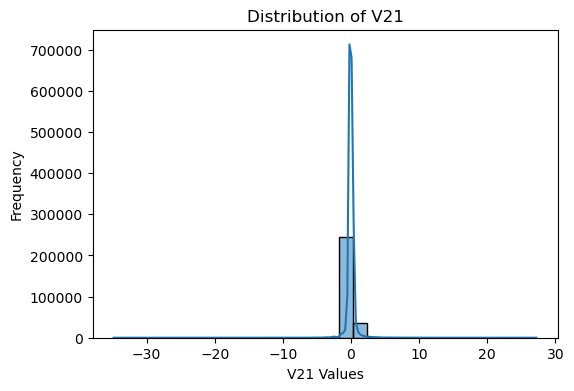

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


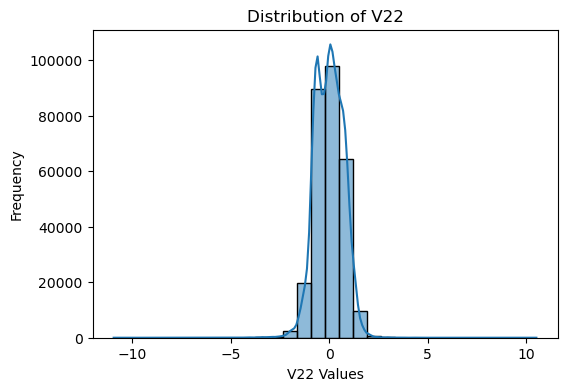

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


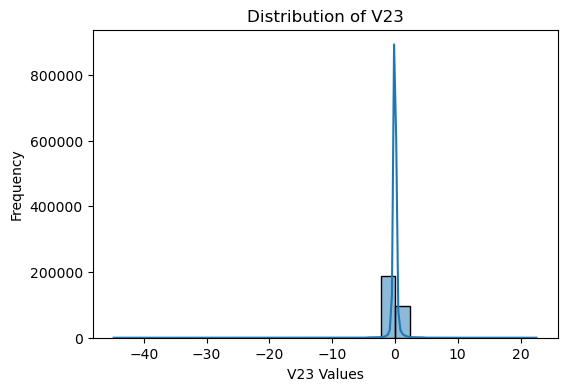

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


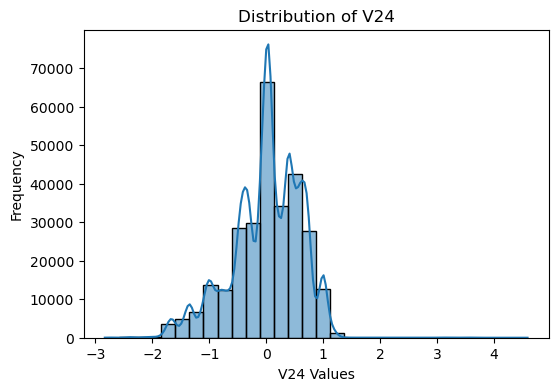

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


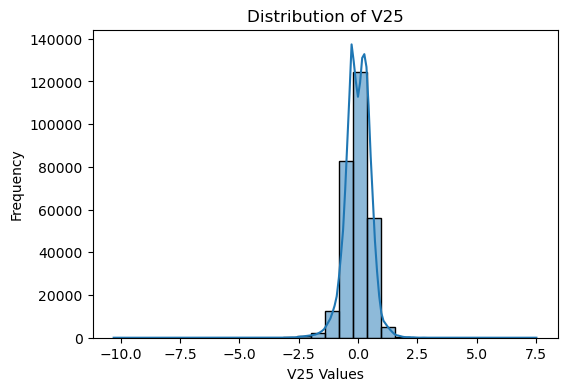

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


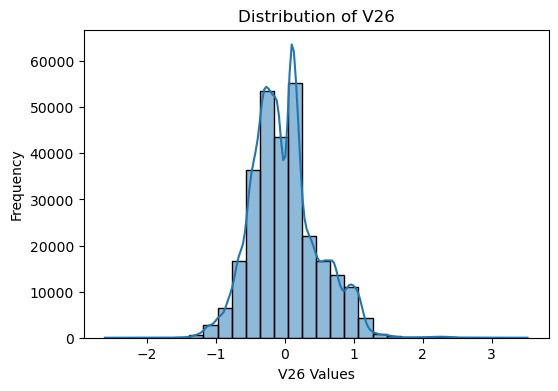

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


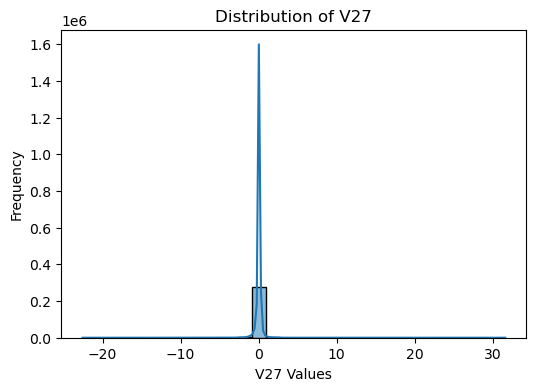

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


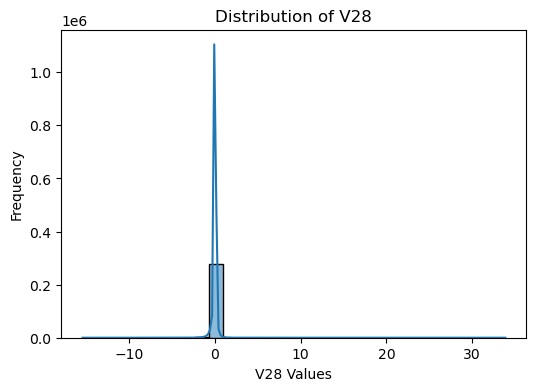

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


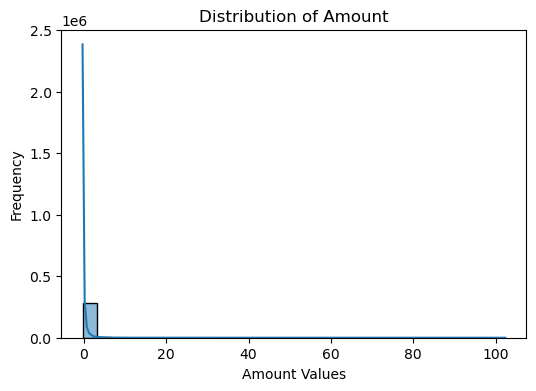

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


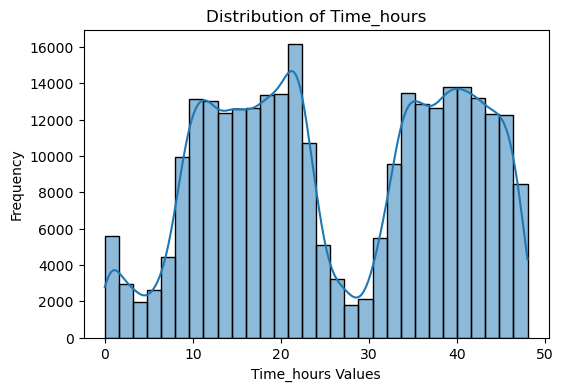

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


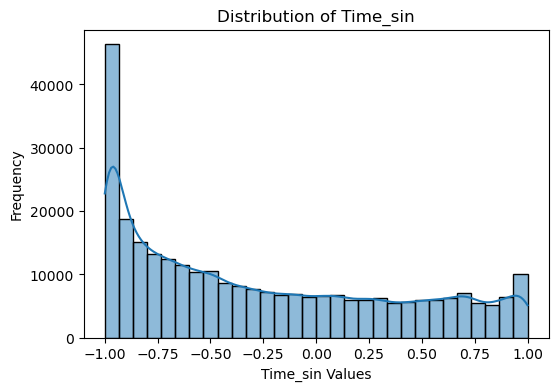

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


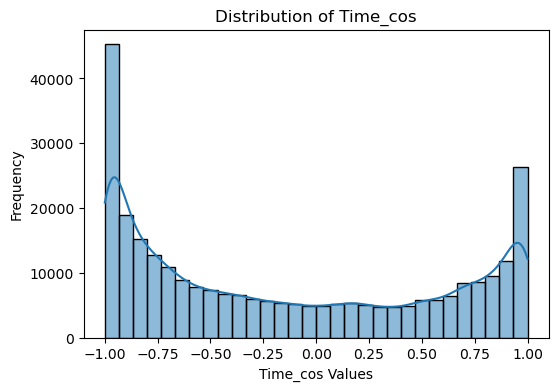

In [ ]:
# List of selected columns for distribution analysis
# (Including all feature columns except target column 'Class')
columns_to_plot = df.drop(columns=['Class']).columns

# Loop through selected columns and plot distributions
for col in columns_to_plot:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.xlabel(col + ' Values')
    plt.ylabel('Frequency')
    plt.title('Distribution of ' + col)
    plt.show()

In [ ]:
# Calculate skewness for all columns
df.skew()

V1            -3.280667
V2            -4.624866
V3            -2.240155
V4             0.676292
V5            -2.425901
V6             1.826581
V7             2.553907
V8            -8.521944
V9             0.554680
V10            1.187141
V11            0.356506
V12           -2.278401
V13            0.065233
V14           -1.995176
V15           -0.308423
V16           -1.100966
V17           -3.844914
V18           -0.259880
V19            0.109192
V20           -2.037155
V21            3.592991
V22           -0.213258
V23           -5.875140
V24           -0.552499
V25           -0.415793
V26            0.576693
V27           -1.170209
V28           11.192091
Amount        16.977724
Class         23.997579
Time_hours    -0.035568
Time_sin       0.537449
Time_cos       0.306237
dtype: float64

In [ ]:
# Correlation analysis
# Calculate correlation matrix for all columns
correlation_matrix = df.corr()

# Round off correlation values to 2 decimal places for easy interpretation
correlation_matrix = correlation_matrix.round(2)

# Display the correlation matrix
correlation_matrix

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Amount,Class,Time_hours,Time_sin,Time_cos
V1,1.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,...,-0.00,-0.00,-0.00,0.00,0.00,-0.23,-0.10,0.12,0.01,-0.01
V2,0.00,1.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,-0.00,-0.00,-0.53,0.09,-0.01,0.01,0.09
V3,-0.00,0.00,1.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,...,0.00,-0.00,-0.00,0.00,0.00,-0.21,-0.19,-0.42,0.03,0.04
V4,-0.00,-0.00,0.00,1.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,...,0.00,0.00,-0.00,0.00,-0.00,0.10,0.13,-0.11,0.03,0.01
V5,0.00,0.00,-0.00,-0.00,1.00,0.00,0.00,0.00,0.00,-0.00,...,-0.00,0.00,0.00,0.00,-0.00,-0.39,-0.09,0.17,0.02,0.01
V6,-0.00,0.00,0.00,-0.00,0.00,1.00,0.00,-0.00,0.00,0.00,...,-0.00,0.00,-0.00,-0.00,0.00,0.22,-0.04,-0.06,0.02,-0.01
V7,-0.00,0.00,0.00,-0.00,0.00,0.00,1.00,0.00,0.00,-0.00,...,0.00,-0.00,-0.00,-0.00,-0.00,0.40,-0.19,0.08,-0.00,-0.01
V8,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,1.00,0.00,-0.00,...,-0.00,-0.00,-0.00,0.00,-0.00,-0.10,0.02,-0.04,-0.02,0.01
V9,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,-0.00,...,-0.00,0.00,-0.00,-0.00,0.00,-0.04,-0.10,-0.01,0.17,0.10
V10,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,1.00,...,-0.00,-0.00,-0.00,-0.00,0.00,-0.10,-0.22,0.03,-0.03,-0.05


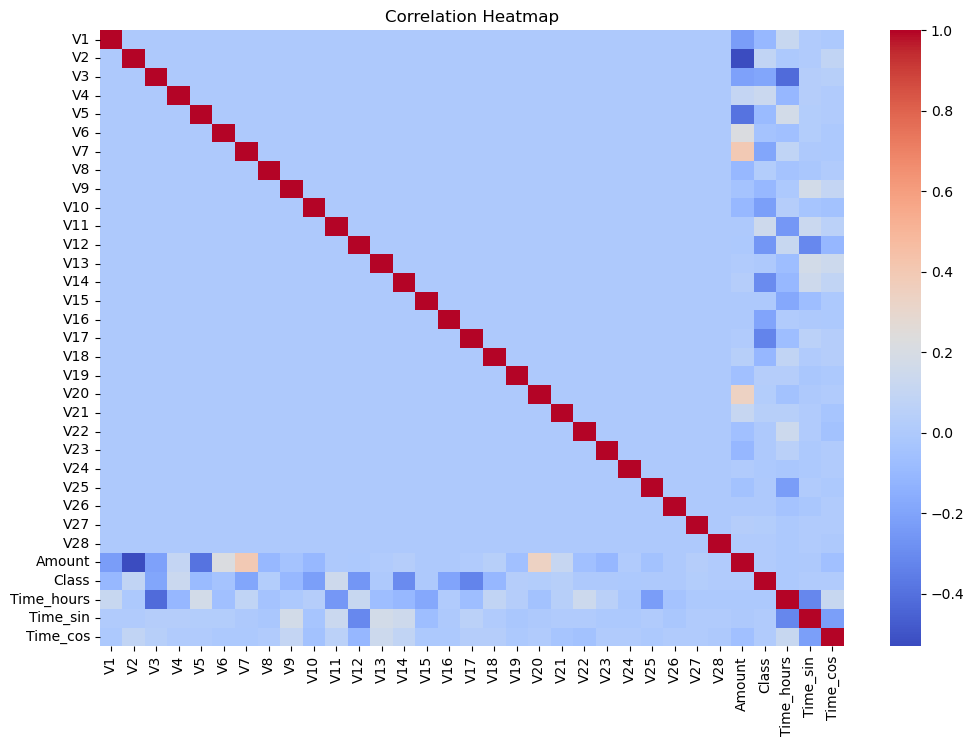

In [ ]:
# Plot heatmap for correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Correlation between V1 and V2
df['V1'].corr(df['V2'])

5.983944040466784e-17

In [ ]:
# Correlation of all features with Class column
df.corr()['Class']

V1           -0.101347
V2            0.091289
V3           -0.192961
V4            0.133447
V5           -0.094974
V6           -0.043643
V7           -0.187257
V8            0.019875
V9           -0.097733
V10          -0.216883
V11           0.154876
V12          -0.260593
V13          -0.004570
V14          -0.302544
V15          -0.004223
V16          -0.196539
V17          -0.326481
V18          -0.111485
V19           0.034783
V20           0.020090
V21           0.040413
V22           0.000805
V23          -0.002685
V24          -0.007221
V25           0.003308
V26           0.004455
V27           0.017580
V28           0.009536
Amount        0.005632
Class         1.000000
Time_hours   -0.012323
Time_sin      0.012808
Time_cos      0.005950
Name: Class, dtype: float64

V1 → Number of outliers: 5522
V2 → Number of outliers: 10924
V3 → Number of outliers: 2415
V4 → Number of outliers: 7996


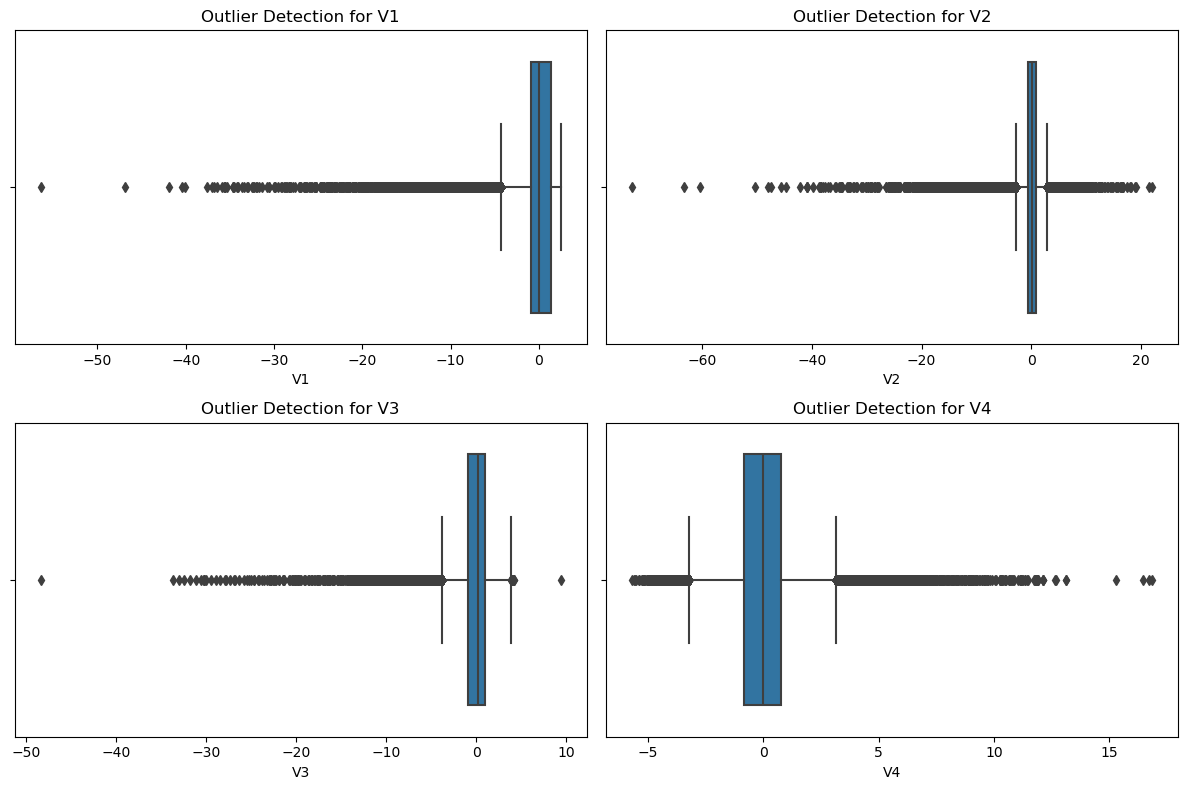

V5 → Number of outliers: 8610
V6 → Number of outliers: 20867
V7 → Number of outliers: 7091
V8 → Number of outliers: 20145


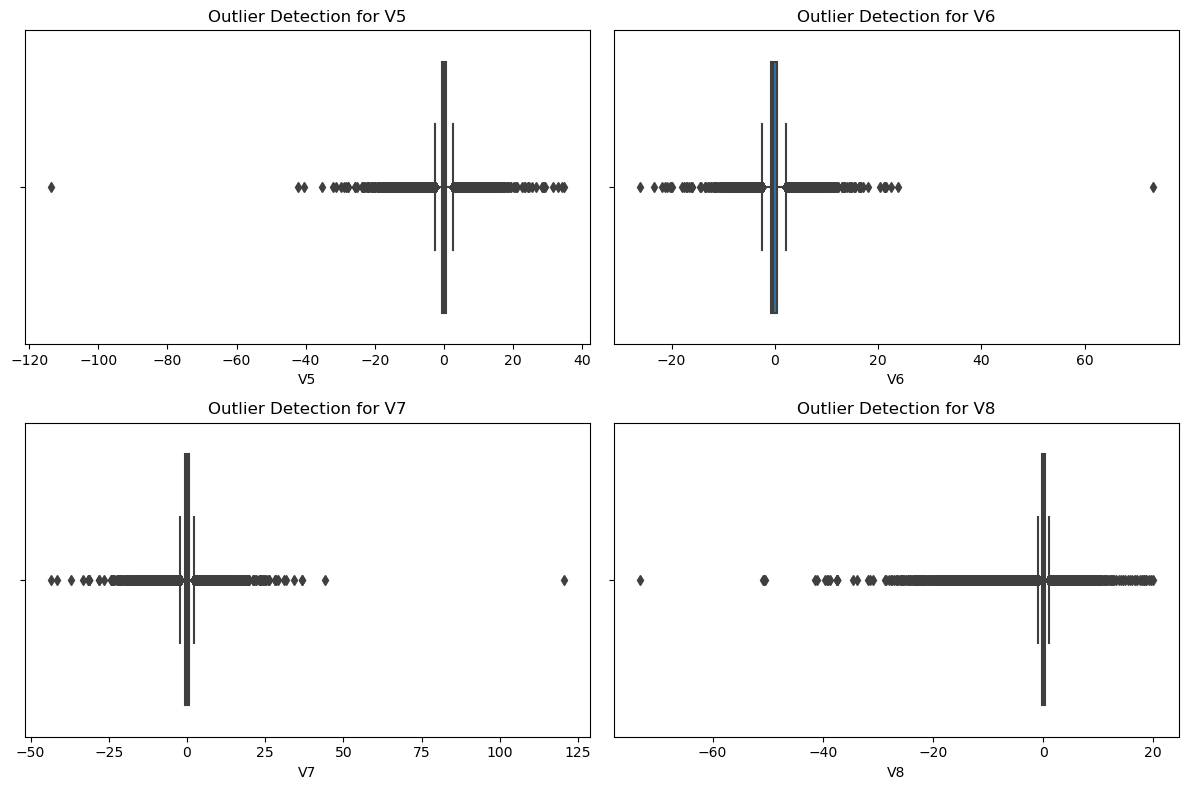

V9 → Number of outliers: 4615
V10 → Number of outliers: 7221
V11 → Number of outliers: 504
V12 → Number of outliers: 11619


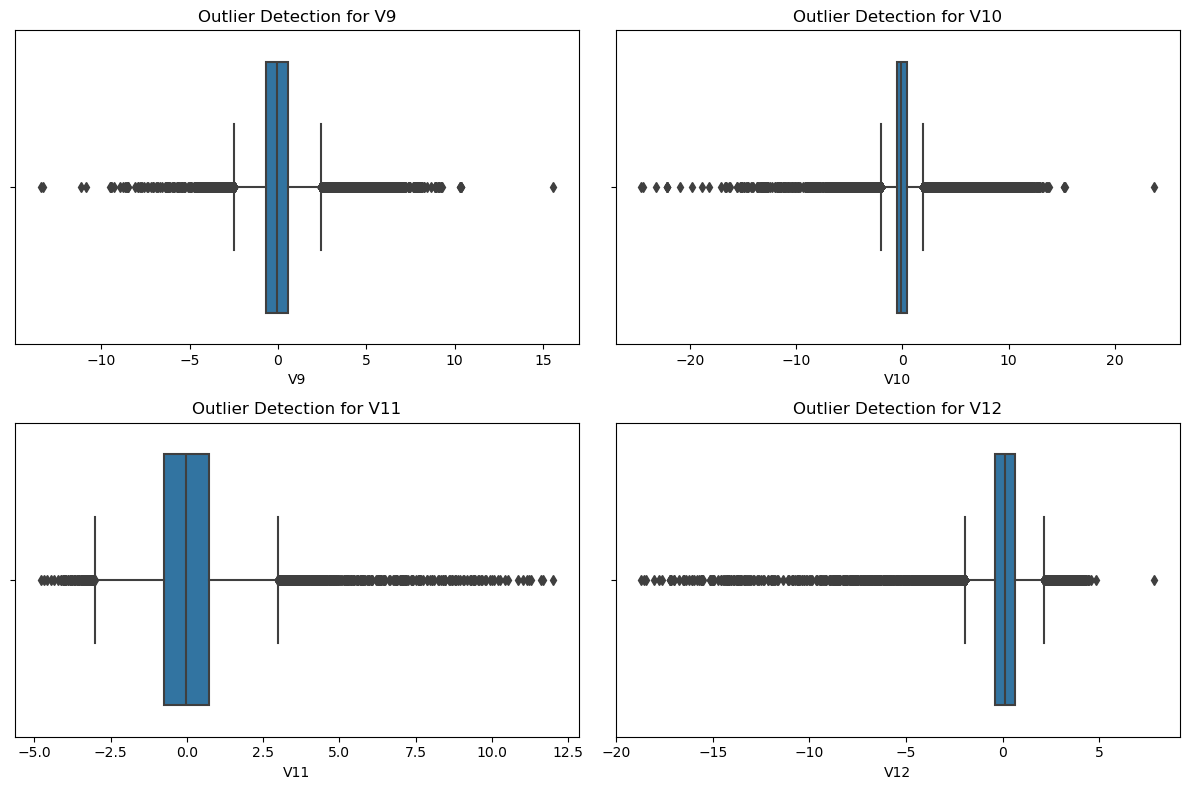

V13 → Number of outliers: 1351
V14 → Number of outliers: 9871
V15 → Number of outliers: 1242
V16 → Number of outliers: 4782


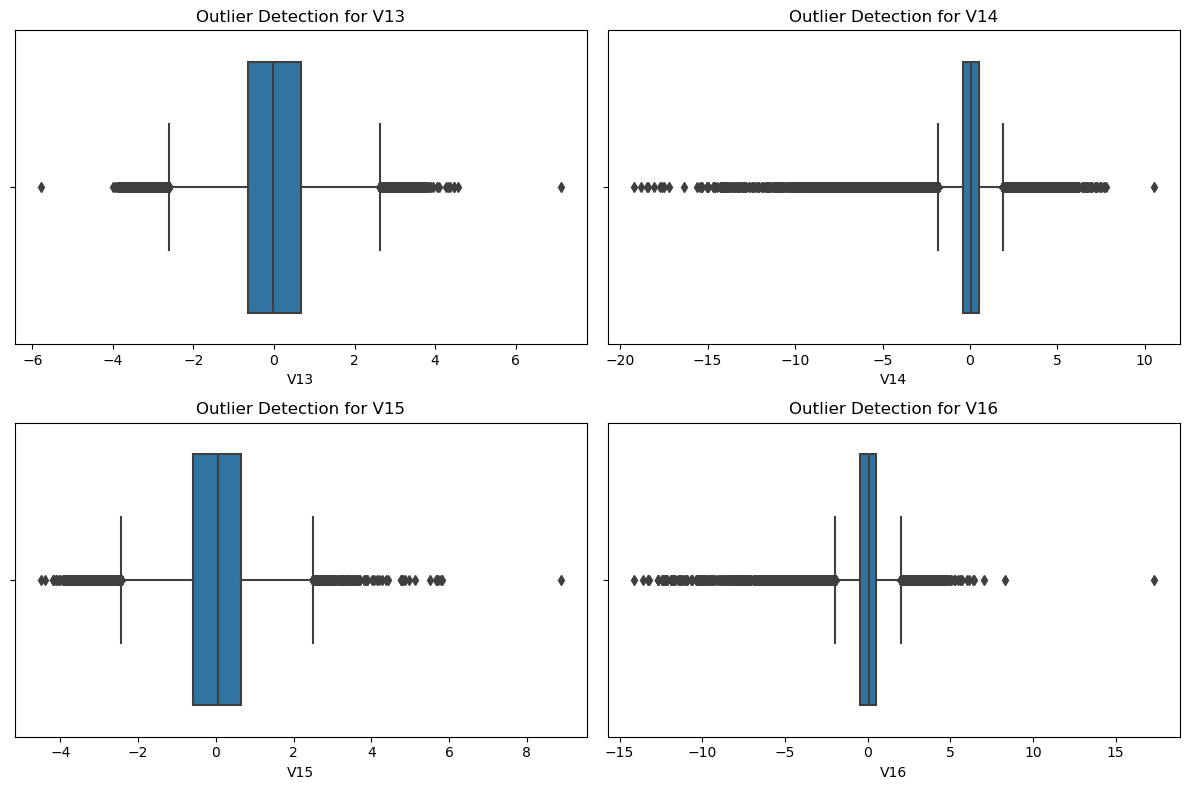

V17 → Number of outliers: 5349
V18 → Number of outliers: 3779
V19 → Number of outliers: 6661
V20 → Number of outliers: 23889


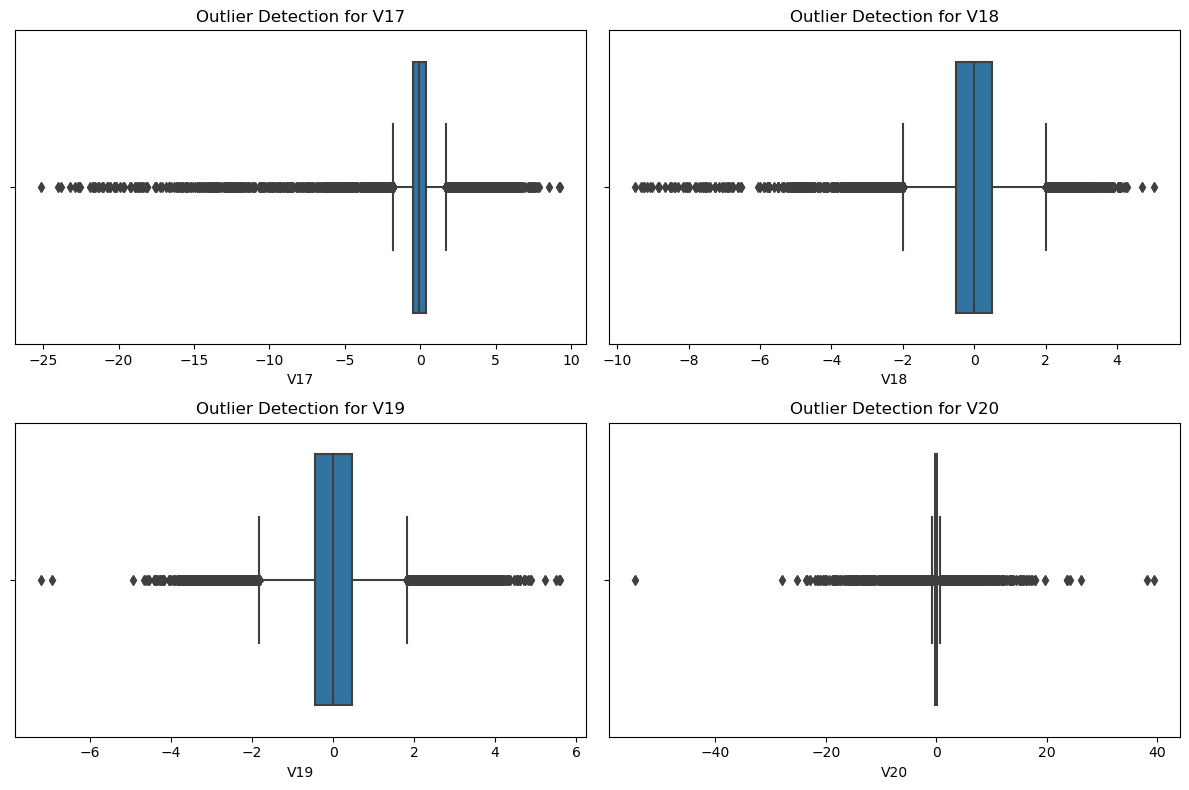

V21 → Number of outliers: 12650
V22 → Number of outliers: 846
V23 → Number of outliers: 15396
V24 → Number of outliers: 1219


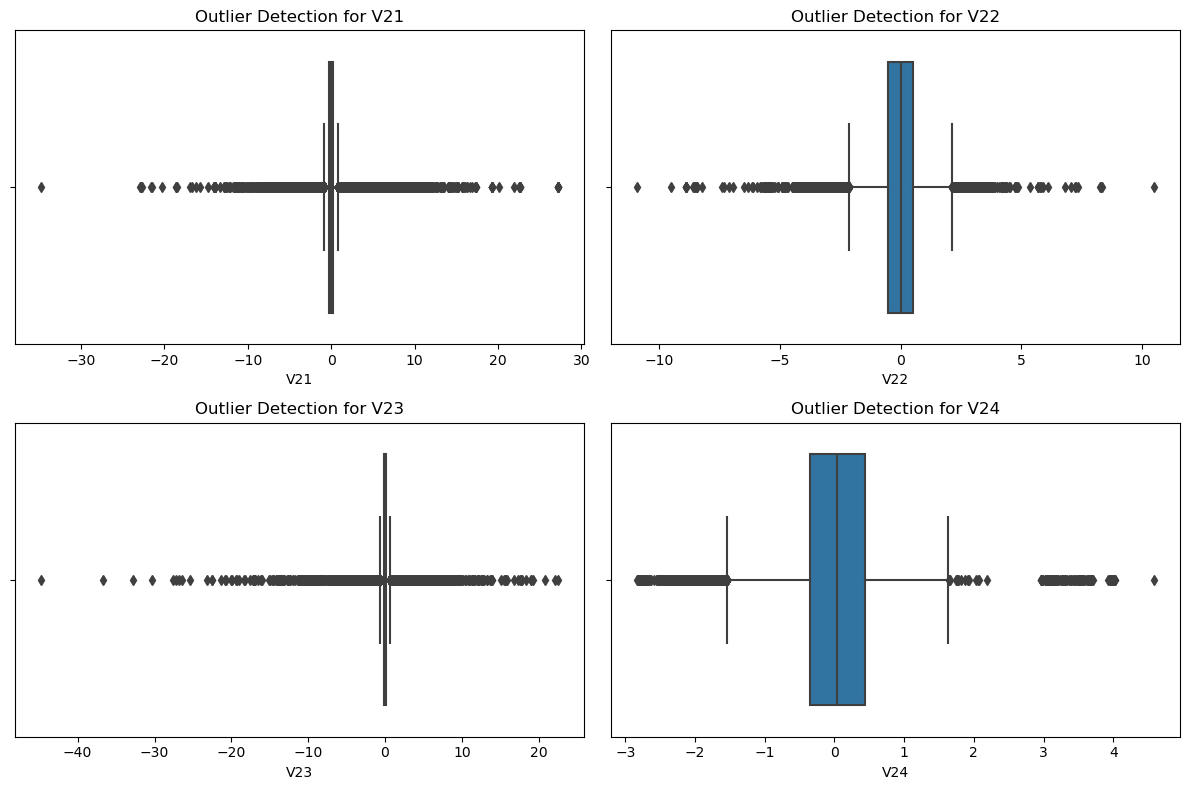

V25 → Number of outliers: 3330
V26 → Number of outliers: 2137
V27 → Number of outliers: 32590
V28 → Number of outliers: 25122


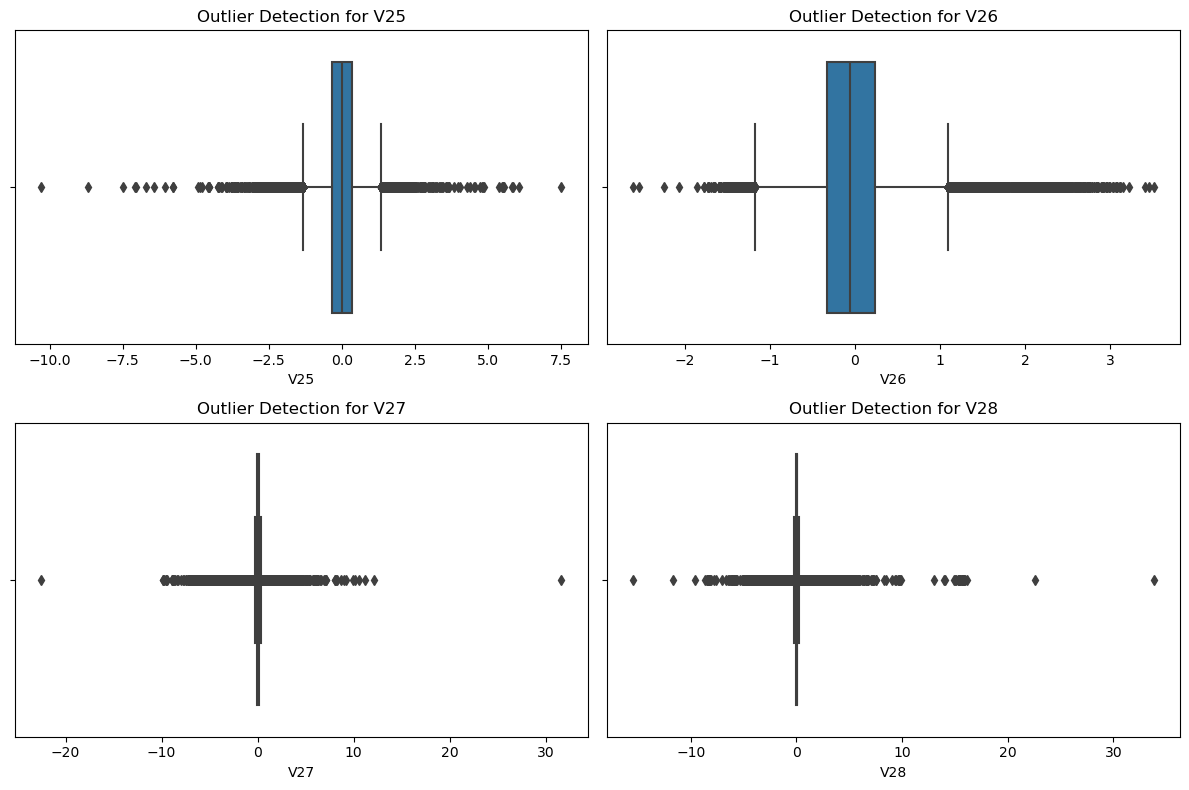

Amount → Number of outliers: 28538
Time_hours → Number of outliers: 0
Time_sin → Number of outliers: 0
Time_cos → Number of outliers: 0


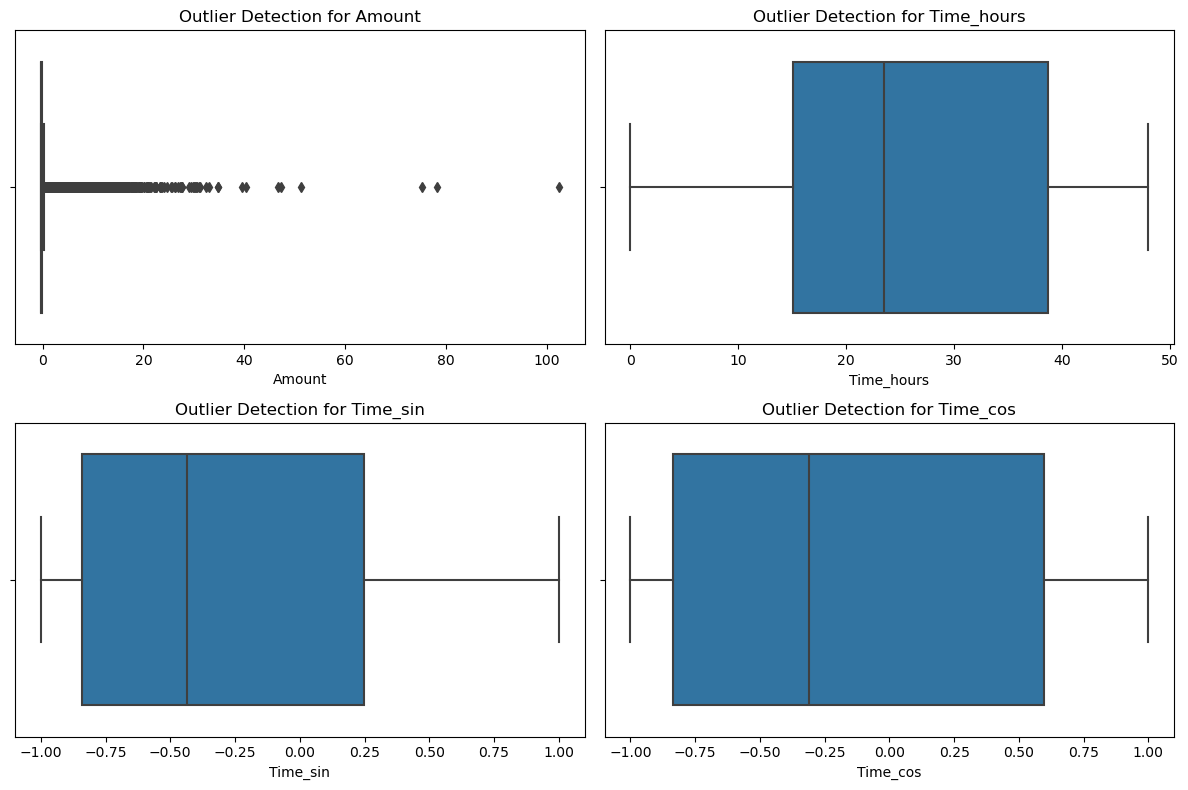

<Figure size 1200x800 with 0 Axes>

In [ ]:
# Outlier detection
import matplotlib.pyplot as plt
import seaborn as sns

# Feature columns excluding target
feature_columns = df.drop(columns=['Class']).columns

plt.figure(figsize=(12,8))   # ADDED

for i, col in enumerate(feature_columns, 1):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Identify outliers using 1.75 IQR
    outliers = df[
        (df[col] < Q1 - 1.75 * IQR) |
        (df[col] > Q3 + 1.75 * IQR)
    ]

    print(f"{col} → Number of outliers: {outliers.shape[0]}")

    plt.subplot(2, 2, ((i-1) % 4) + 1)   # ADDED: 2x2 layout
    sns.boxplot(x=df[col])
    plt.title('Outlier Detection for ' + col)

    if i % 4 == 0:                       # ADDED: show every 4 plots
        plt.tight_layout()
        plt.show()
        plt.figure(figsize=(12,8))

plt.tight_layout()
plt.show()

In [ ]:
# Outlier removal
# Check original dataset shape
print("Original dataset shape:", df.shape)

# Create a copy of the dataset for cleaning
df_clean = df.copy()

for col in feature_columns:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.75 * IQR
    upper_bound = Q3 + 1.75 * IQR

    # Calculate mean of column
    mean_value = df_clean[col].mean()

    # Replace outliers with mean
    df_clean.loc[df_clean[col] < lower_bound, col] = mean_value
    df_clean.loc[df_clean[col] > upper_bound, col] = mean_value

print("Outlier treatment completed using mean replacement.")

Original dataset shape: (284807, 33)
Outlier treatment completed using mean replacement.


C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

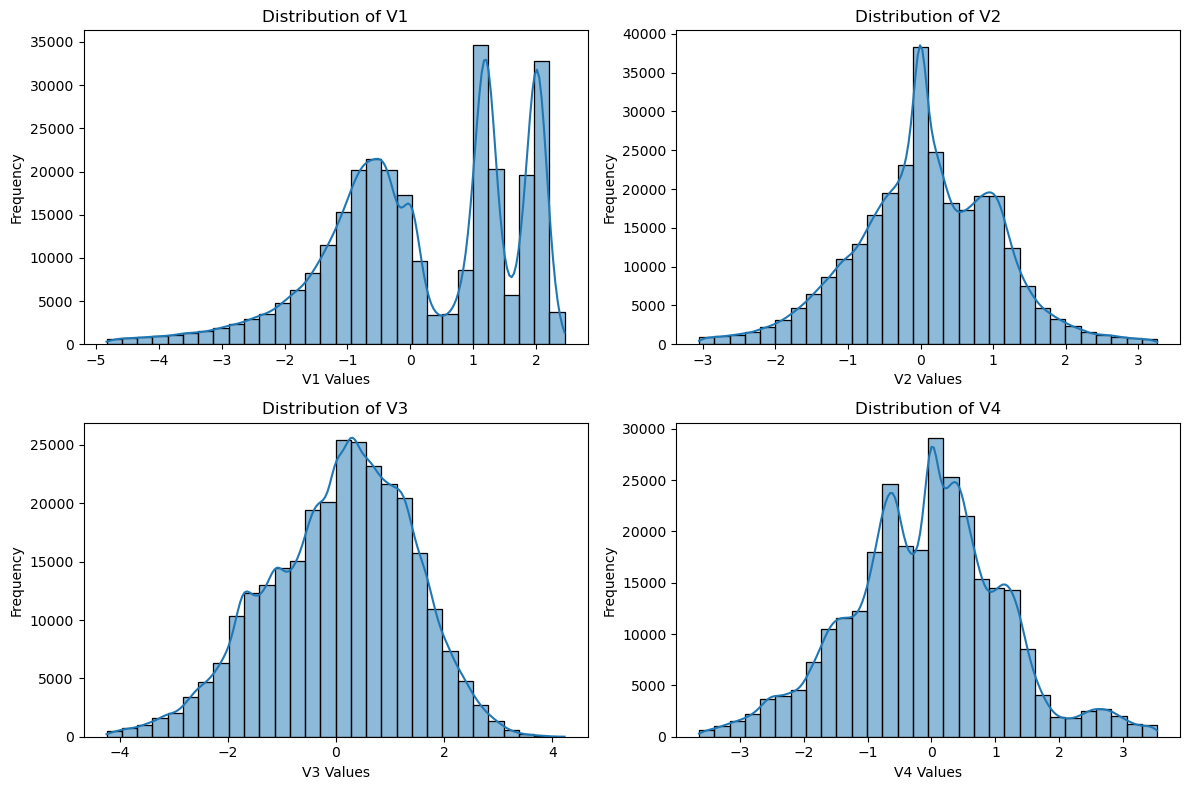

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

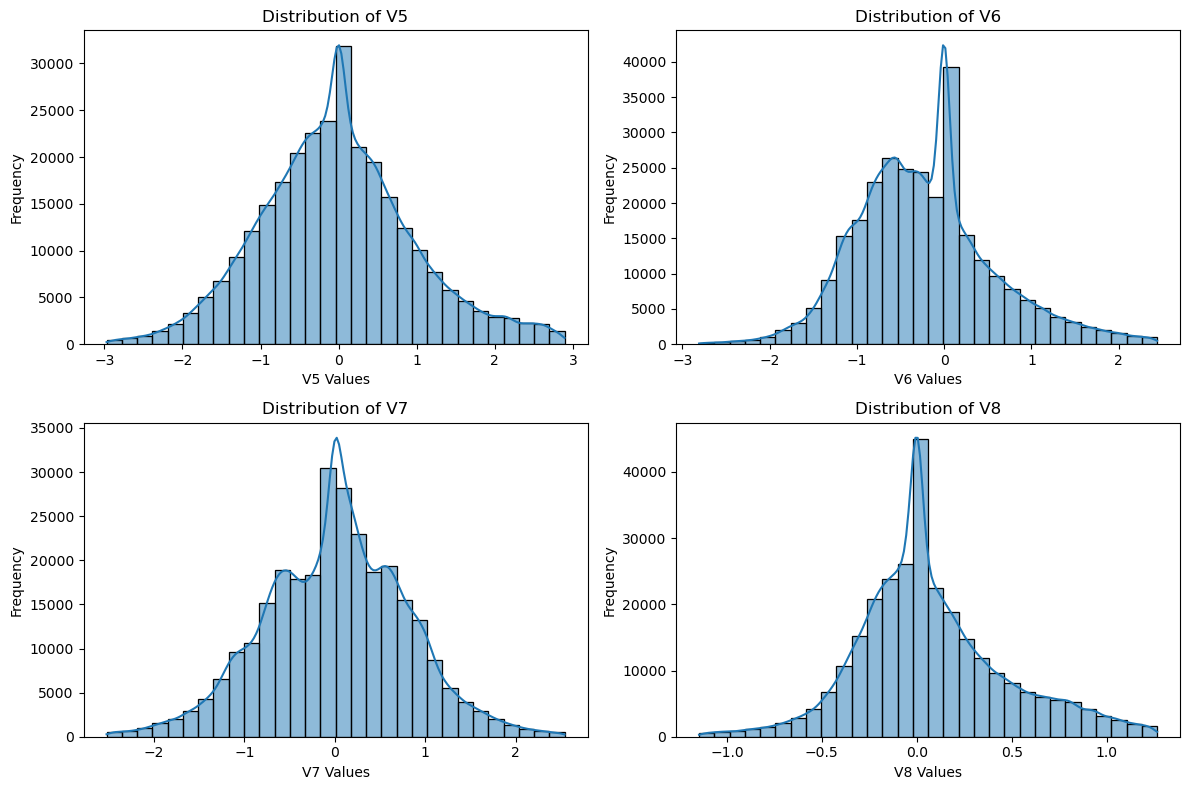

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

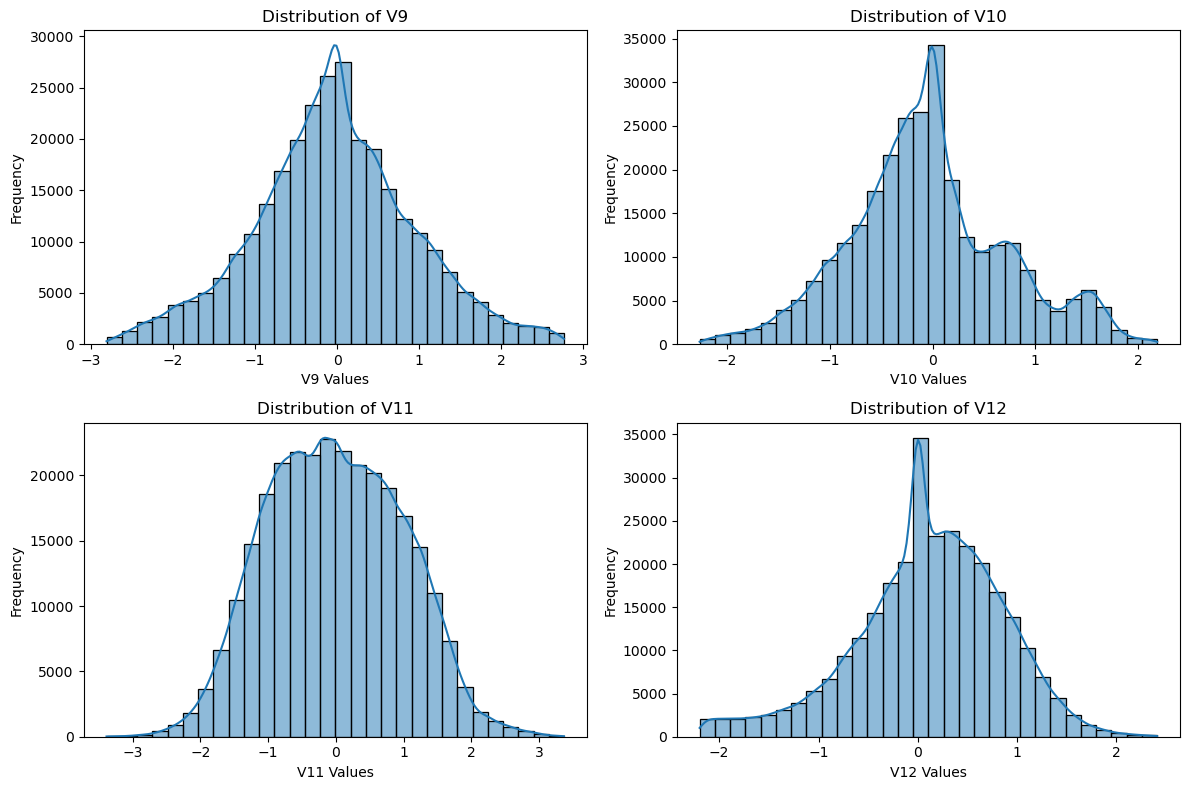

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

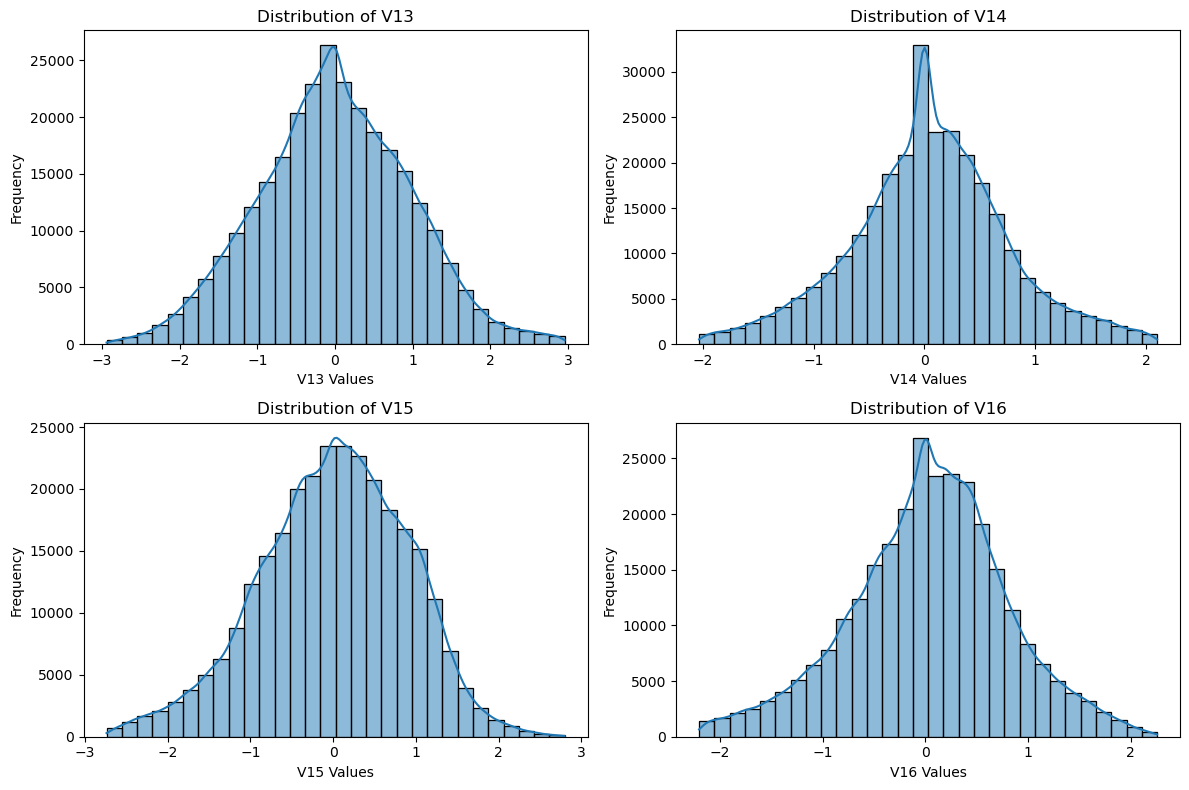

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

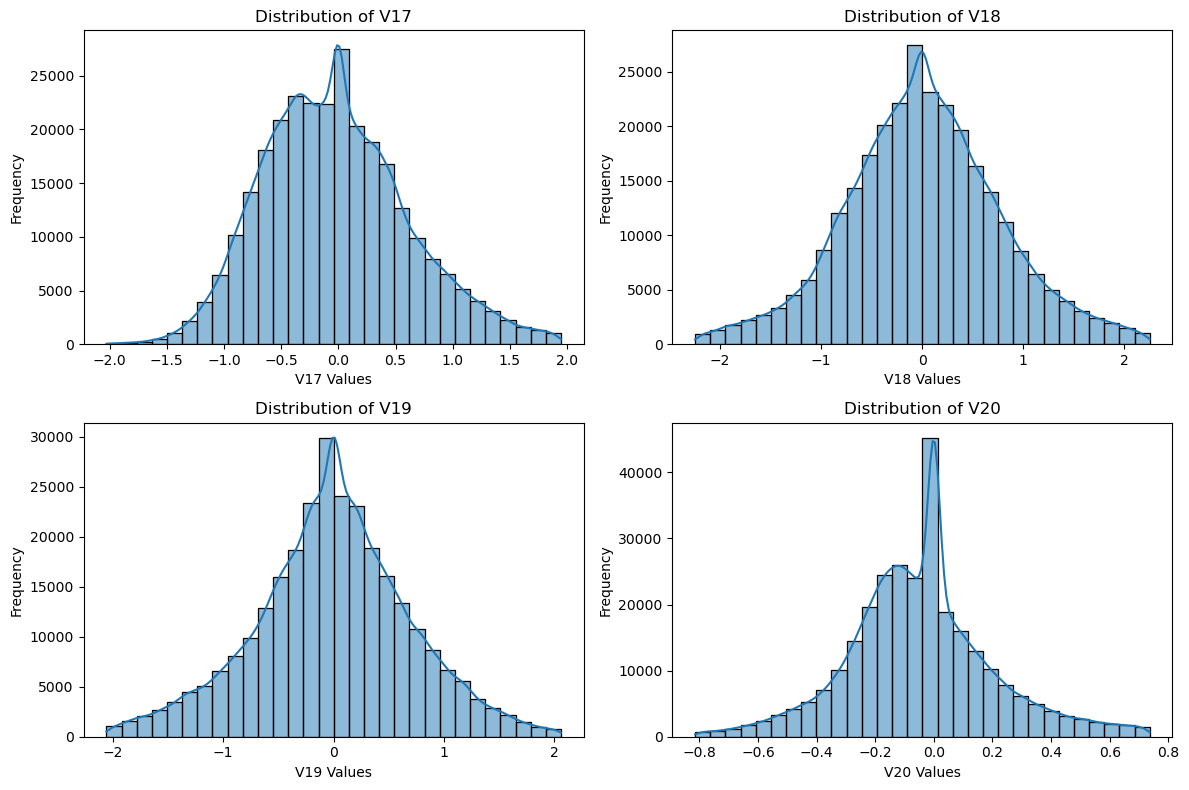

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

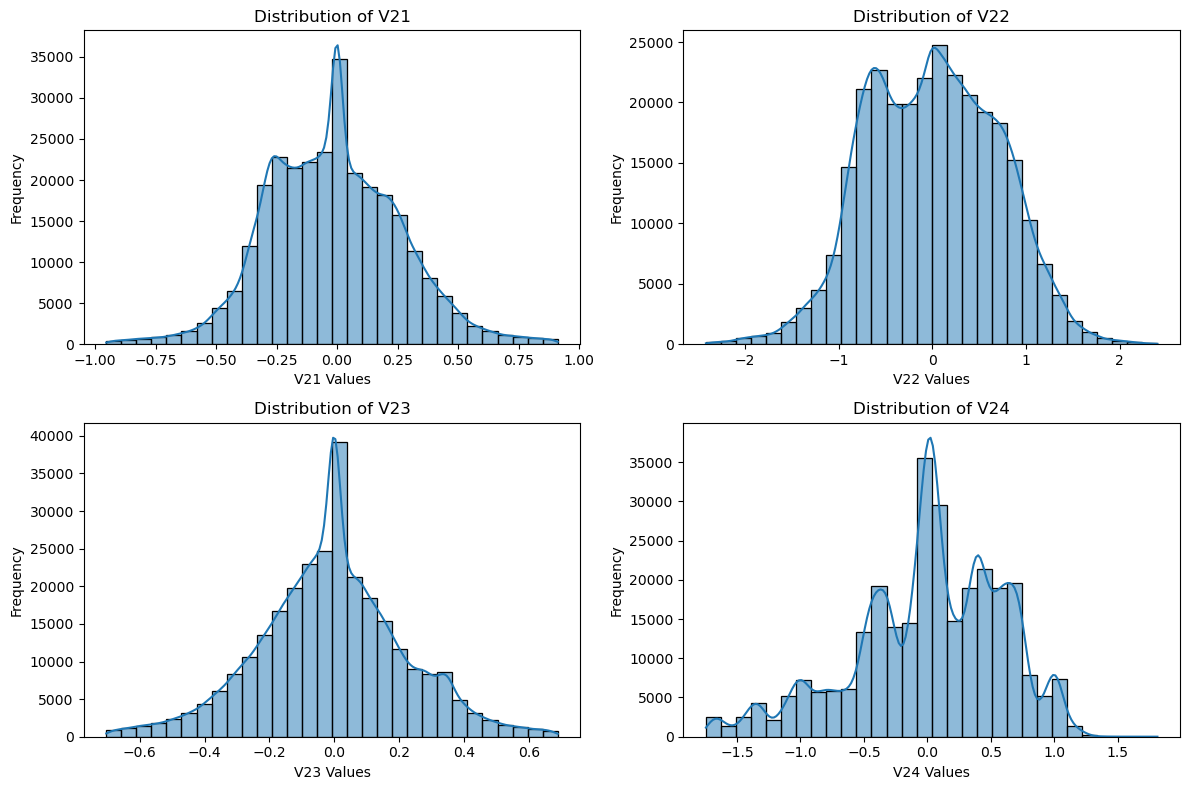

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

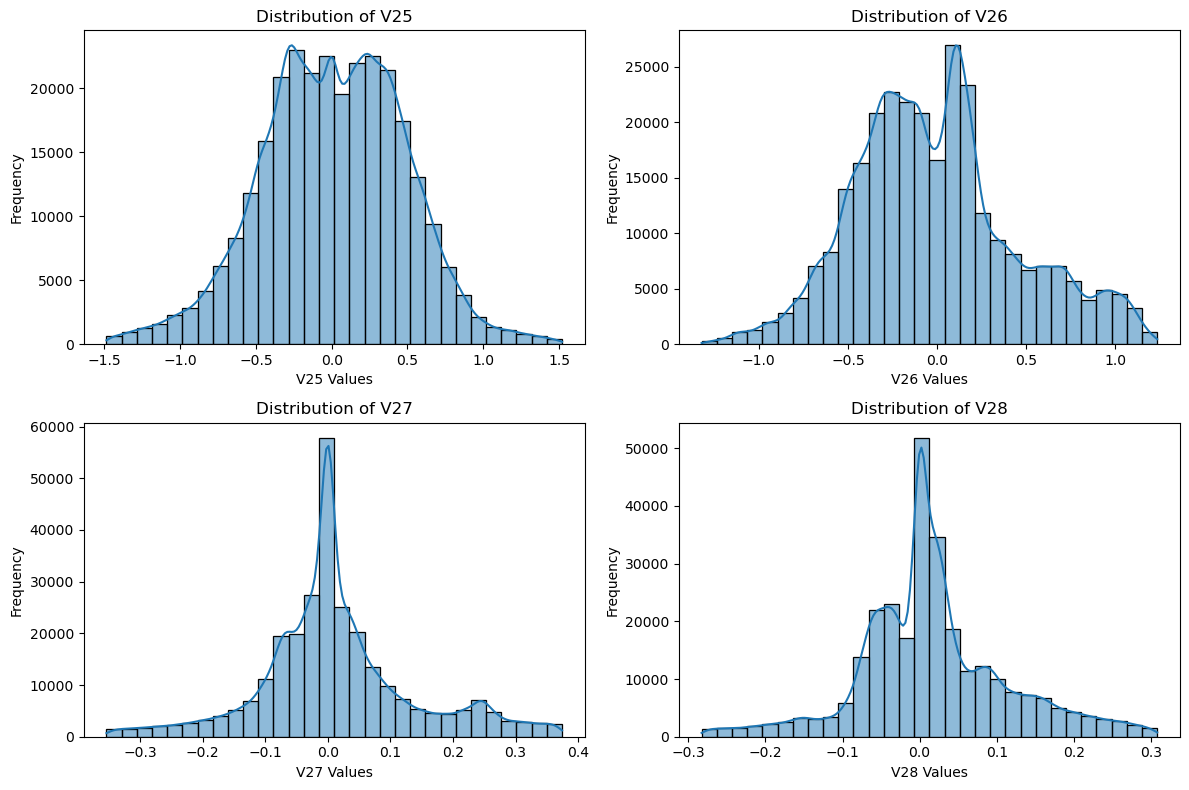

C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mythr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

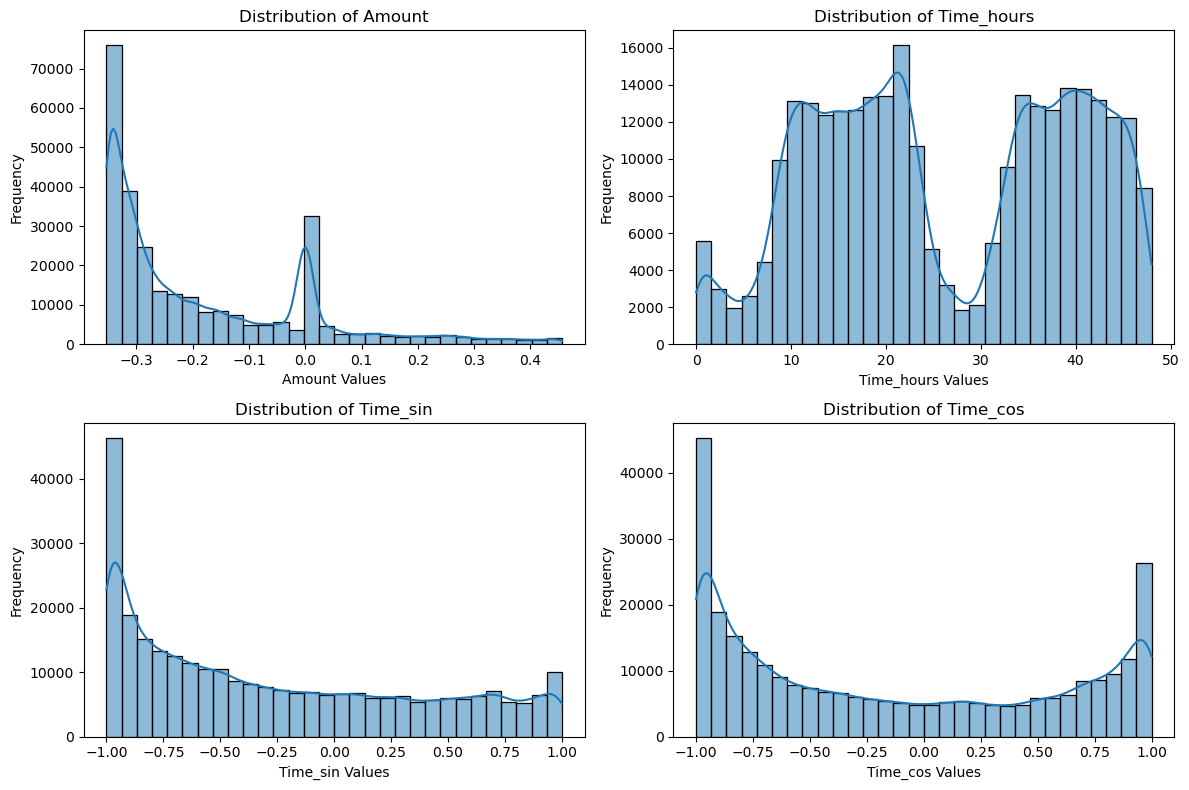

<Figure size 1200x800 with 0 Axes>

In [ ]:
# Distribution after outlier treatment

import matplotlib.pyplot as plt
import seaborn as sns

# Feature columns excluding target
feature_columns = df_clean.drop(columns=['Class']).columns

plt.figure(figsize=(12,8))

for i, col in enumerate(feature_columns, 1):

    plt.subplot(2, 2, ((i-1) % 4) + 1)   # 2x2 layout

    sns.histplot(df_clean[col], bins=30, kde=True)
    plt.title('Distribution of ' + col)
    plt.xlabel(col + ' Values')
    plt.ylabel('Frequency')

    if i % 4 == 0:
        plt.tight_layout()
        plt.show()
        plt.figure(figsize=(12,8))

plt.tight_layout()
plt.show()

In [ ]:
# Save the cleaned dataset to a CSV file
df_clean.to_csv("fraud_detection_cleaned.csv", index=False)

In [ ]:
# PRE REQUISITE VALIDATION
# Import required libraries
import pandas as pd
import numpy as np

In [ ]:
#LOGISTIC REGRESSION
#Check Target Variable is Binary (Class = 0 or 1)

# Check unique values in target column
df_clean['Class'].unique()

# Interpretation: Logistic Regression needs binary target (0 and 1)

array([0, 1], dtype=int64)

In [ ]:
# Count values of each class
df_clean['Class'].value_counts()

# Interpretation: Shows how many fraud and non-fraud cases are present

Class
0    284315
1       492
Name: count, dtype: int64

In [ ]:
# Check Multicollinearity using Correlation Matrix (Rule: |r| > 0.8 is high)

# Calculate correlation matrix
corr_matrix = df_clean.drop(columns=['Class']).corr()

# Round correlation values to 2 decimals for easy viewing
corr_matrix = corr_matrix.round(2)

# Display correlation matrix
corr_matrix

# Interpretation: High correlation (above 0.8) can cause multicollinearity in Logistic Regression

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount,Time_hours,Time_sin,Time_cos
V1,1.00,-0.38,-0.37,0.12,-0.12,-0.08,-0.22,-0.20,0.15,0.24,...,0.15,0.00,0.07,-0.00,-0.12,-0.18,-0.05,0.15,0.01,-0.02
V2,-0.38,1.00,0.06,0.17,0.32,-0.09,0.42,0.01,-0.05,-0.23,...,-0.07,0.02,-0.08,0.01,0.15,0.13,-0.42,-0.02,0.00,0.10
V3,-0.37,0.06,1.00,0.07,-0.24,0.25,-0.09,0.16,-0.01,-0.05,...,-0.15,0.00,0.01,-0.01,0.16,0.16,-0.01,-0.48,0.04,0.04
V4,0.12,0.17,0.07,1.00,0.01,0.13,0.07,-0.02,0.14,-0.01,...,0.01,-0.00,0.04,-0.06,-0.04,0.01,-0.02,-0.17,0.02,0.01
V5,-0.12,0.32,-0.24,0.01,1.00,-0.10,0.40,0.02,-0.04,-0.17,...,-0.10,-0.02,0.01,-0.00,0.04,0.00,-0.25,0.20,0.04,0.01
V6,-0.08,-0.09,0.25,0.13,-0.10,1.00,-0.27,0.40,0.04,0.08,...,-0.05,-0.32,-0.05,-0.00,0.07,0.03,0.18,-0.11,0.02,-0.03
V7,-0.22,0.42,-0.09,0.07,0.40,-0.27,1.00,-0.37,-0.08,-0.23,...,-0.19,-0.01,-0.03,-0.00,-0.06,0.07,-0.03,0.11,0.01,0.00
V8,-0.20,0.01,0.16,-0.02,0.02,0.40,-0.37,1.00,-0.00,-0.12,...,0.06,-0.02,-0.07,-0.01,0.17,0.08,0.01,-0.10,-0.05,0.01
V9,0.15,-0.05,-0.01,0.14,-0.04,0.04,-0.08,-0.00,1.00,-0.38,...,0.07,-0.00,-0.03,0.02,-0.02,-0.10,-0.05,0.00,0.16,0.10
V10,0.24,-0.23,-0.05,-0.01,-0.17,0.08,-0.23,-0.12,-0.38,1.00,...,0.09,-0.01,-0.05,-0.02,-0.04,-0.11,0.04,0.03,-0.03,-0.08


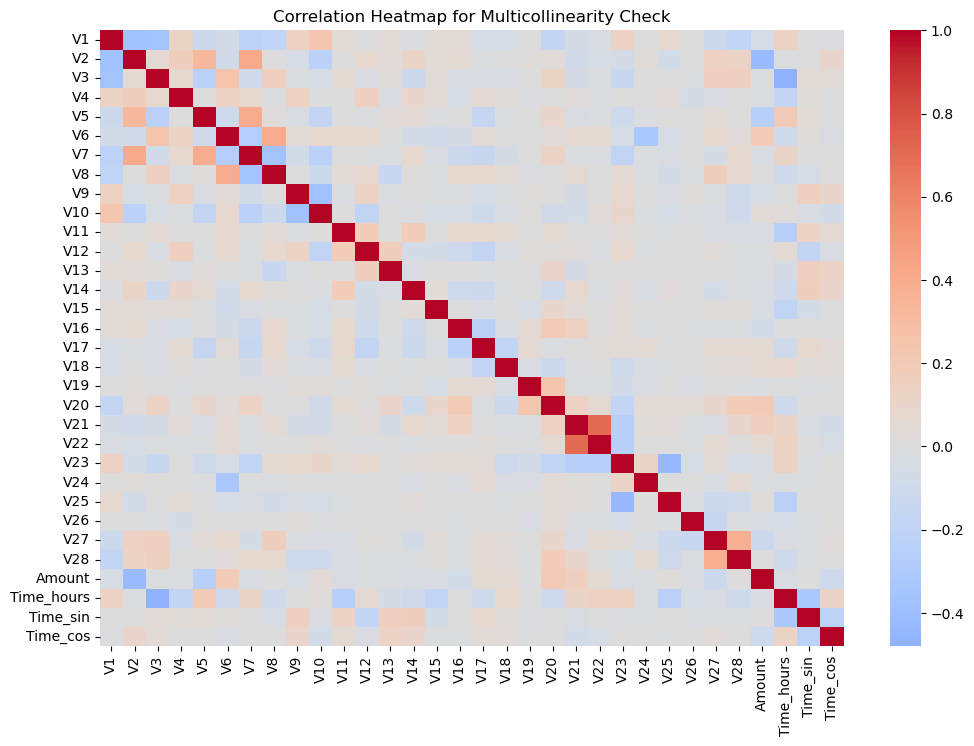

In [ ]:
# Visualization of correlation matrix to check multicollinearity

import matplotlib.pyplot as plt
import seaborn as sns

# Plot heatmap for correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)

plt.title('Correlation Heatmap for Multicollinearity Check')
plt.show()

In [ ]:
# Set correlation threshold
threshold = 0.8

# Get absolute correlation matrix
corr_matrix = df_clean.drop(columns=['Class']).corr().abs()

# Select upper triangle of correlation matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identify columns with correlation greater than threshold
to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > threshold)
]

# Display columns to drop
print("Columns to drop due to multicollinearity:", to_drop)

Columns to drop due to multicollinearity: []


In [ ]:
# Drop highly correlated columns
df_reduced = df_clean.drop(columns=to_drop)

# Check new shape
print("Original shape:", df_clean.shape)
print("Shape after dropping multicollinear features:", df_reduced.shape)

Original shape: (284807, 33)
Shape after dropping multicollinear features: (284807, 33)


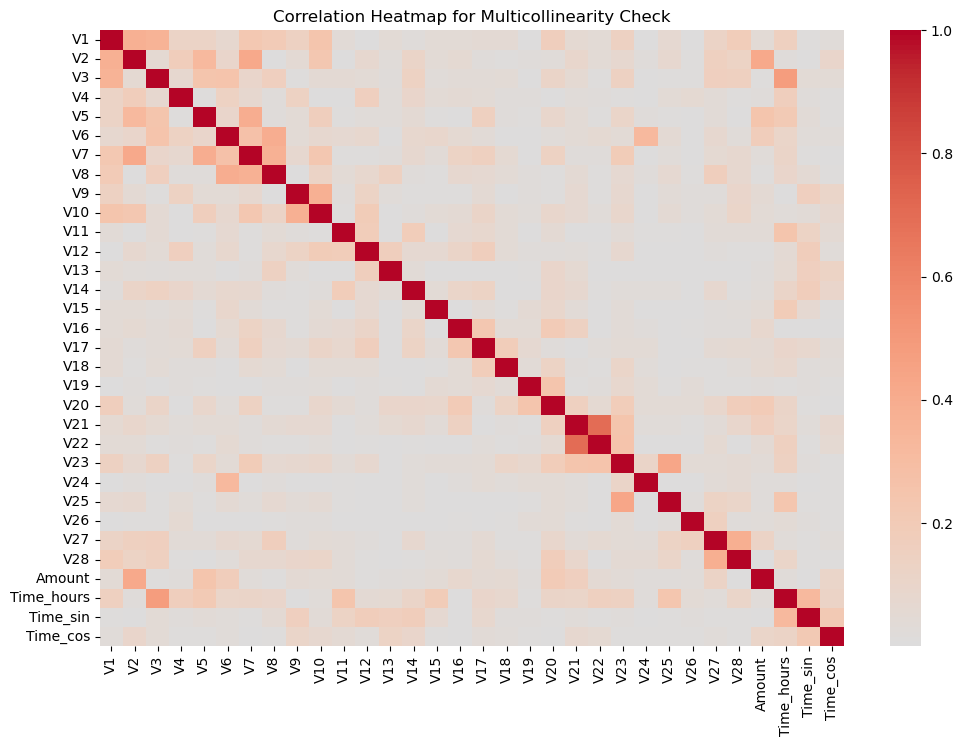

In [ ]:
# Visualization of correlation matrix to check multicollinearity

import matplotlib.pyplot as plt
import seaborn as sns

# Plot heatmap for correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)

plt.title('Correlation Heatmap for Multicollinearity Check')
plt.show()

In [ ]:
# Check Class Imbalance (Rule: Fraud < 10% means imbalance)

# Check class percentage distribution
(df_clean['Class'].value_counts(normalize=True) * 100)

# Interpretation: If fraud percentage is very low, dataset is imbalanced

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [ ]:
# Check class distribution
df_clean['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [ ]:
# Separate majority and minority classes
df_majority = df_clean[df_clean['Class'] == 0]
df_minority = df_clean[df_clean['Class'] == 1]

# Randomly remove 95% of majority class rows
df_majority_undersampled = df_majority.sample(
    frac=0.05,          # keep only 5%
    random_state=42
)

# Combine minority class with undersampled majority class
df_balanced = pd.concat([df_majority_undersampled, df_minority])

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42)

# Check new class distribution
df_balanced['Class'].value_counts()

Class
0    14216
1      492
Name: count, dtype: int64

In [ ]:
# Scaling Check (Already handled, but verify Amount/feature scale)

# Check summary statistics to understand feature scaling
df_clean.describe()

# Interpretation: Features should be on a similar scale for Logistic Regression

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Amount,Class,Time_hours,Time_sin,Time_cos
count,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,2.848070e+05,284807.000000,284807.000000,...,284807.000000,284807.000000,284807.000000,2.848070e+05,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000
mean,0.156968,0.074364,0.058393,-0.093311,-0.023936,-0.224844,0.013384,7.273958e-02,-0.037867,-0.050575,...,0.005984,0.010802,-0.010396,1.347570e-02,0.016867,-0.184485,0.001727,26.337183,-0.266787,-0.140733
std,1.477447,0.984247,1.326799,1.202615,0.982939,0.787994,0.791631,3.957793e-01,0.972600,0.764671,...,0.589235,0.472999,0.459354,1.249602e-01,0.097622,0.183773,0.041527,13.191152,0.628132,0.717268
min,-4.833047,-3.051600,-4.243521,-3.634449,-2.971888,-2.809959,-2.521732,-1.146557e+00,-2.813465,-2.266679,...,-1.744246,-1.485706,-1.320863,-3.541349e-01,-0.282621,-0.353229,0.000000,0.000000,-1.000000,-1.000000
25%,-0.849552,-0.517714,-0.841669,-0.837475,-0.659083,-0.758143,-0.520269,-1.687368e-01,-0.633059,-0.519756,...,-0.347885,-0.306022,-0.326449,-5.049986e-02,-0.038542,-0.330840,0.000000,15.055972,-0.841236,-0.837083
50%,0.018109,0.033683,0.179845,-0.007915,-0.029505,-0.264249,0.020292,1.213481e-16,-0.044550,-0.081448,...,0.040649,0.011692,-0.051161,-3.660091e-16,0.005654,-0.265271,0.000000,23.525556,-0.435624,-0.311920
75%,1.315642,0.757720,1.027179,0.649857,0.547708,0.167774,0.543587,2.718475e-01,0.556662,0.380502,...,0.438833,0.346739,0.227131,6.103524e-02,0.062629,-0.044717,0.000000,38.700139,0.247422,0.597800
max,2.454930,3.257590,4.226108,3.529116,2.892739,2.440052,2.538315,1.265249e+00,2.767180,2.185201,...,1.810991,1.519227,1.234831,3.743398e-01,0.307948,0.455943,1.000000,47.997778,1.000000,1.000000


In [ ]:
#RANDOM FOREST
# Check Target Variable is Binary

# Check unique values in target column
df_clean['Class'].unique()

# Interpretation: Random Forest for classification also needs target labels like 0 and 1

array([0, 1], dtype=int64)

In [ ]:
# Check Class Imbalance (Important even for Random Forest)

# Check class percentage distribution
(df_clean['Class'].value_counts(normalize=True) * 100)

# Interpretation: Class imbalance affects performance, so it must be handled during training

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [ ]:
# Separate majority and minority classes
df_majority = df_clean[df_clean['Class'] == 0]
df_minority = df_clean[df_clean['Class'] == 1]

print("Majority (0) rows:", df_majority.shape[0])
print("Minority (1) rows:", df_minority.shape[0])

Majority (0) rows: 284315
Minority (1) rows: 492


In [ ]:
# Number of parts to split majority class
num_parts = 5

# Split majority data into equal parts
majority_parts = np.array_split(df_majority, num_parts)

C:\Users\mythr\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
# Dataset Size Check

# Check dataset shape
df_clean.shape

# Interpretation: More data helps Random Forest create better trees

(284807, 33)

In [ ]:
print("Prerequisite checks completed for Logistic Regression and Random Forest.")

Prerequisite checks completed for Logistic Regression and Random Forest.


In [ ]:
# Import basic libraries
import pandas as pd
import numpy as np

# For train-test split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# For model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Separate independent variables (features) and target variable
X = df.drop(columns=['Class'])   # Features
y = df['Class']                  # Target

# Check shapes
X.shape, y.shape

((284807, 32), (284807,))

In [ ]:
# Split data into training and testing sets
# 70% training, 30% testing
# stratify=y ensures the same proportion of fraud (1) and non-fraud (0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Check split sizes
X_train.shape, X_test.shape

((199364, 32), (85443, 32))

In [ ]:
# Create Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression with class weight adjustment
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

# Train the model
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# Predict on test data
y_pred_lr = log_reg.predict(X_test)

# Accuracy score
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

# Confusion matrix
confusion_matrix(y_test, y_pred_lr)

Logistic Regression Accuracy: 0.9786290275388271


array([[83489,  1806],
       [   20,   128]], dtype=int64)

In [ ]:
# Classification report
print(classification_report(y_test, y_pred_lr))
# Precision: Out of predicted fraud cases, how many are actually fraud
# Recall: Out of actual fraud cases, how many were correctly identified
# F1-score: Harmonic mean of precision and recall (balance between both)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.86      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.56     85443
weighted avg       1.00      0.98      0.99     85443



In [ ]:
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

models = []  # to store trained models

for i, part in enumerate(majority_parts):

    # Combine one part of majority with all minority
    df_part = pd.concat([part, df_minority])

    # Shuffle data
    df_part = df_part.sample(frac=1, random_state=42)

    # Separate features and target
    X = df_part.drop(columns=['Class'])
    y = df_part['Class']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Random Forest model
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    )

    # Train model
    rf.fit(X_train, y_train)

    # Store model
    models.append(rf)

    print(f"Random Forest model trained on part {i+1}")

Random Forest model trained on part 1
Random Forest model trained on part 2
Random Forest model trained on part 3
Random Forest model trained on part 4
Random Forest model trained on part 5


In [ ]:
# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Accuracy score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

# Confusion matrix
confusion_matrix(y_test, y_pred_rf)

Random Forest Accuracy: 0.9916894287208694


array([[17059,     0],
       [  143,     5]], dtype=int64)

In [ ]:
# Classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     17059
           1       1.00      0.03      0.07       148

    accuracy                           0.99     17207
   macro avg       1.00      0.52      0.53     17207
weighted avg       0.99      0.99      0.99     17207



In [ ]:
# Compare accuracy of both models
print("Logistic Regression Accuracy:", accuracy_lr)
print("Random Forest Accuracy:", accuracy_rf)

Logistic Regression Accuracy: 0.9786290275388271
Random Forest Accuracy: 0.9916894287208694


In [ ]:
# MODEL COMPARISION

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)

#Logistic Regression Predictions
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

#Random Forest (5 Parts) Predictions
rf_probs = []

for model in models:
    rf_probs.append(model.predict_proba(X_test)[:, 1])

rf_probs = np.array(rf_probs)

# Average probabilities from 5 models
y_prob_rf = np.mean(rf_probs, axis=0)

# Convert to class labels
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

#Metrics Calculation

# Logistic Metrics
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_prob_lr)

precision_curve_lr, recall_curve_lr, _ = precision_recall_curve(y_test, y_prob_lr)
pr_auc_lr = auc(recall_curve_lr, precision_curve_lr)

# Random Forest Metrics
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

precision_curve_rf, recall_curve_rf, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc_rf = auc(recall_curve_rf, precision_curve_rf)

#Create Comparison DataFrame

comparison_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"],
    "Logistic Regression (95%)": [
        precision_lr,
        recall_lr,
        f1_lr,
        roc_lr,
        pr_auc_lr
    ],
    "Random Forest (5 Parts)": [
        precision_rf,
        recall_rf,
        f1_rf,
        roc_rf,
        pr_auc_rf
    ]
})

print(comparison_df)

#Confusion Matrices
print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nRandom Forest (5 Parts) Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

      Metric  Logistic Regression (95%)  Random Forest (5 Parts)
0  Precision                   0.213235                 0.023523
1     Recall                   0.195946                 0.939189
2   F1-Score                   0.204225                 0.045897
3    ROC-AUC                   0.708381                 0.944539
4     PR-AUC                   0.076648                 0.873045

Logistic Regression Confusion Matrix:
[[16952   107]
 [  119    29]]

Random Forest (5 Parts) Confusion Matrix:
[[11289  5770]
 [    9   139]]
